In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import trimesh
#this is entirely AI generated code to create a Menger sponge (mesh) of a given order, meant only to validate my own FD calculations.

def voxel_to_mesh(voxels):
    """
    Convert a 3D voxel array to a mesh with vertices and triangle faces.
    
    voxels: 3D numpy array (1=solid, 0=empty)
    Returns: Trimesh object
    """
    # Get the coordinates of all filled voxels
    filled = np.argwhere(voxels)
    
    # List to hold individual voxel meshes
    cube_meshes = []
    
    for x, y, z in filled:
        # Create a unit cube at (x, y, z)
        cube = trimesh.creation.box(extents=(1,1,1), transform=trimesh.transformations.translation_matrix([x, y, z]))
        cube_meshes.append(cube)
    
    # Merge all cubes into a single mesh
    combined = trimesh.util.concatenate(cube_meshes)
    return combined

# Example: create mesh from Menger Sponge voxels
def menger_sponge(order):
    """Generate voxel-based Menger Sponge."""
    def recurse(n):
        if n == 0:
            return np.ones((1, 1, 1), dtype=int)
        small = recurse(n - 1)
        size = small.shape[0]
        sponge = np.zeros((size*3, size*3, size*3), dtype=int)
        for x in range(3):
            for y in range(3):
                for z in range(3):
                    if (x==1 and y==1) or (x==1 and z==1) or (y==1 and z==1):
                        continue
                    sponge[x*size:(x+1)*size,
                           y*size:(y+1)*size,
                           z*size:(z+1)*size] = small
        return sponge
    return recurse(order)

# Generate sponge
order = 4  # higher orders = more cubes
voxels = menger_sponge(order)

# Convert to mesh
mesh = voxel_to_mesh(voxels)

# Access vertices and faces
vertices = mesh.vertices
faces = mesh.faces

print("Vertices shape:", vertices.shape)
print("Faces shape:", faces.shape)


Vertices shape: (1280000, 3)
Faces shape: (1920000, 3)


In [5]:

def surf_box_counting(box_size):
    x_pos= np.arange(x_min, x_max, box_size)
    y_pos = np.arange(y_min, y_max, box_size)
    z_pos= np.arange(z_min, z_max, box_size)
    counter=0
    for x in x_pos:
        for y in y_pos:
            for z in z_pos:
                cube = ((vertices[:,0]>= x) & (vertices[:,0]< x+box_size) & (vertices[:,1]>= y) & (vertices[:,1]< y+box_size) & (vertices[:,2]>= z) & (vertices [:,2]< z+box_size))
                if np.any(cube):
                    counter+=1


    return counter

In [6]:


x_min = np.min(vertices[:,0])
x_max = np.max(vertices[:,0])
y_min = np.min(vertices[:,1])
y_max = np.max(vertices[:,1])
z_min = np.min(vertices[:,2])
z_max = np.max(vertices[:,2])

x= np.zeros(40)
y= np.zeros(40)
idx=0
for i in range(1, 27):
    if 27 % i == 0:
        number_of_boxes = surf_box_counting(i)
        box_size = i
        # x is the x axis of our graph, representing box size
        x[idx] = int(box_size)
        y[idx]= int(number_of_boxes)
        idx += 1
x = x.astype(int)
y = y.astype(int)   
y=y[0:idx]
x=x[0:idx]



log_x= np.log(x)
log_y=np.log(y)

widest_range = 0 
best_fd = 0
best_r2 = 0
min_j = 0
max_k = 0
for j in range(1, idx):
    for k in range(1, idx):
        if k > j:
            rf_log_x = log_x[j:k+1]
            rf_log_y = log_y[j:k+1]
            slope, intercept, r_value, p_value, std_err = stats.linregress(rf_log_x, rf_log_y)
            r2 = r_value**2
            fd = -slope
            if 0.995 < r2 < 1: 
                if r2>=best_r2 and k-j> widest_range:
                    widest_range = k - j
                    min_j = j
                    max_k = k
                    best_fd = fd
                    best_r2 = r2    

print("Fractal Dimension is: ", best_fd)
print("its R-squared value is: ", best_r2)
print("ideal range is from box sizes: ", x[min_j] , " to ", x[max_k])

Fractal Dimension is:  2.788632232961528
its R-squared value is:  0.9999999999999998
ideal range is from box sizes:  3  to  9


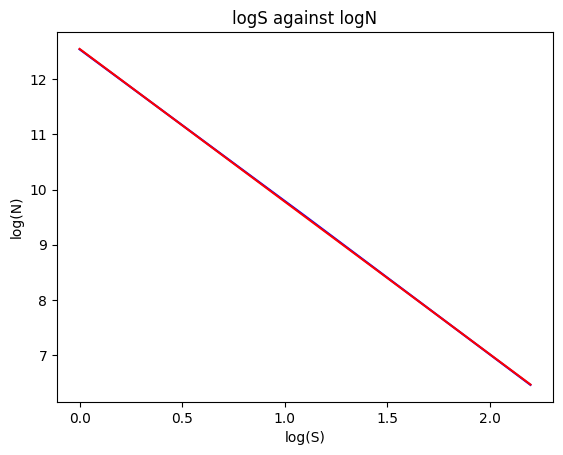

Fractal Dimension is:  2.770101752205696
R-squared value is:  0.9999850839374145


In [7]:
#use this to explore how the log-log graph changes at different ranges, with a line of best fit!
rf_log_x = log_x[0:3]
rf_log_y = log_y[0:3]
plt.plot(rf_log_x,rf_log_y,color='blue')
plt.title('logS against logN')
plt.xlabel("log(S)")
plt.ylabel('log(N)')
m, c = np.polyfit(rf_log_x, rf_log_y, 1)
plt.plot(rf_log_x, m*rf_log_x + c, color='red')  # Plot
plt.show()

print("Fractal Dimension is: ", -m)
correlation_coefficient = np.corrcoef(rf_log_x, rf_log_y)[0, 1]
r2 = correlation_coefficient**2
print("R-squared value is: ", r2)